In [64]:
# Save Segmented Clients Data
output_columns = ['client_id', 'client_type', 'first_name', 'last_name', 'age', 'satisfaction_score',
                   'property_count', 'total_spent', 'avg_price', 'cluster']

output_df = segmentation_df[output_columns].copy()
output_df.to_csv('../outputs/segmented_clients.csv', index=False)

print("✓ Segmented clients data saved to: ../outputs/segmented_clients.csv")
print(f"\nOutput file preview:")
print(output_df.head(10))
print(f"\nTotal rows saved: {len(output_df)}")

✓ Segmented clients data saved to: ../outputs/segmented_clients.csv

Output file preview:
  client_id client_type first_name last_name        age  satisfaction_score  \
0     C0001  Individual     Kareem       Liu  58.067077                   4   
1     C0002  Individual    Trystan   Oconnor        NaN                   1   
2     C0003  Individual       Kale       Gay  67.162218                   4   
3     C0004  Individual    Russell     Gross        NaN                   5   
4     C0005     Company    Marleez        Co        NaN                   5   
5     C0006  Individual      Yurem    Wright  69.248460                   3   
6     C0007  Individual     Xavier  Faulkner        NaN                   5   
7     C0008  Individual     Kayden     Olsen        NaN                   5   
8     C0009  Individual    Joaquin   Mullins  50.666667                   5   
9     C0010  Individual    Nicolas   Navarro        NaN                   3   

   property_count  total_spent      avg_

In [59]:
# Create Segment Names and Profiles
segment_profiles = {}

for cluster_id in sorted(output_df['cluster'].unique()):
    cluster_data = output_df[output_df['cluster'] == cluster_id]
    
    avg_age = cluster_data['age'].mean()
    avg_satisfaction = cluster_data['satisfaction_score'].mean()
    avg_spent = cluster_data['total_spent'].mean()
    company_pct = (cluster_data['client_type'] == 'Company').sum() / len(cluster_data) * 100
    
    # Segment naming logic
    if avg_spent > output_df['total_spent'].quantile(0.75):
        segment_type = "💎 Premium Spenders"
    elif company_pct > 30:
        segment_type = "🏢 Corporate Buyers"
    elif avg_satisfaction > 4:
        segment_type = "😊 Satisfied Customers"
    elif avg_age < output_df['age'].median():
        segment_type = "🚀 Young Professionals"
    else:
        segment_type = "👥 Regular Customers"
    
    segment_profiles[cluster_id] = {
        'name': segment_type,
        'size': len(cluster_data),
        'avg_age': avg_age,
        'avg_satisfaction': avg_satisfaction,
        'avg_spent': avg_spent,
        'company_pct': company_pct,
        'avg_properties': cluster_data['property_count'].mean()
    }

# Display profiles
print("\n" + "="*100)
print("SEGMENT PROFILES")
print("="*100 + "\n")

for cluster_id, profile in segment_profiles.items():
    print(f"CLUSTER {cluster_id}: {profile['name']}")
    print(f"  • Size: {profile['size']:,} customers")
    print(f"  • Average Age: {profile['avg_age']:.1f} years")
    print(f"  • Average Satisfaction: {profile['avg_satisfaction']:.2f}/5")
    print(f"  • Average Spending: ${profile['avg_spent']:,.0f}")
    print(f"  • Companies: {profile['company_pct']:.1f}%")
    print(f"  • Avg Properties: {profile['avg_properties']:.1f}")
    print()


SEGMENT PROFILES

CLUSTER 0: 💎 Premium Spenders
  • Size: 89 customers
  • Average Age: 66.2 years
  • Average Satisfaction: 3.57/5
  • Average Spending: $2,130,533
  • Companies: 1.1%
  • Avg Properties: 6.3

CLUSTER 1: 👥 Regular Customers
  • Size: 922 customers
  • Average Age: 56.0 years
  • Average Satisfaction: 2.96/5
  • Average Spending: $1,027,349
  • Companies: 0.0%
  • Avg Properties: 3.5

CLUSTER 2: 🏢 Corporate Buyers
  • Size: 102 customers
  • Average Age: 48.1 years
  • Average Satisfaction: 3.05/5
  • Average Spending: $1,240,326
  • Companies: 100.0%
  • Avg Properties: 3.6

CLUSTER 3: 🚀 Young Professionals
  • Size: 887 customers
  • Average Age: 54.2 years
  • Average Satisfaction: 3.04/5
  • Average Spending: $1,417,593
  • Companies: 0.0%
  • Avg Properties: 3.5



## Segment Profiling & Naming

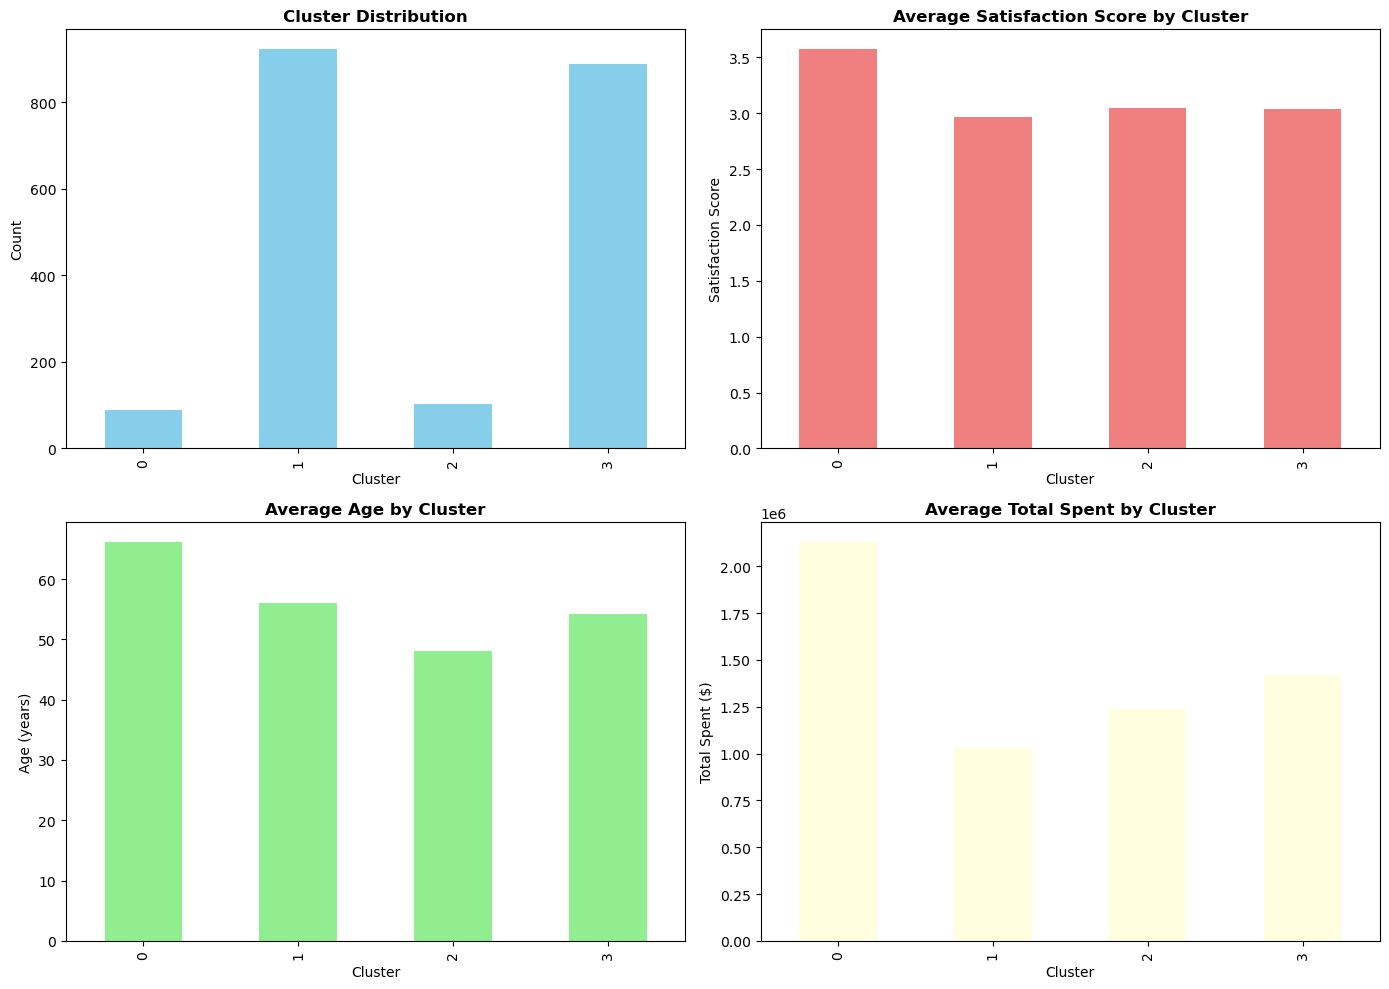

Cluster analysis plots saved!


In [63]:
# Cluster Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Cluster distribution
segmentation_df['cluster'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Cluster Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Cluster')
axes[0, 0].set_ylabel('Count')

# Average satisfaction by cluster
segmentation_df.groupby('cluster')['satisfaction_score'].mean().plot(kind='bar', ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Average Satisfaction Score by Cluster', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Cluster')
axes[0, 1].set_ylabel('Satisfaction Score')

# Average age by cluster
segmentation_df.groupby('cluster')['age'].mean().plot(kind='bar', ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Average Age by Cluster', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Cluster')
axes[1, 0].set_ylabel('Age (years)')

# Average total spent by cluster
segmentation_df.groupby('cluster')['total_spent'].mean().plot(kind='bar', ax=axes[1, 1], color='lightyellow')
axes[1, 1].set_title('Average Total Spent by Cluster', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Total Spent ($)')

plt.tight_layout()
plt.savefig('../outputs/figures/cluster_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Cluster analysis plots saved!")

In [62]:
# Analyze Clusters
print("\nCluster Analysis:")
print("="*80)

cluster_analysis = segmentation_df.groupby('cluster').agg({
    'age': 'mean',
    'satisfaction_score': 'mean',

    'property_count': 'mean',
    'total_spent': 'mean',
    'avg_price': 'mean',
    'client_type': lambda x: (x == 'Company').sum(),
    'client_id': 'count'
}).round(2)

cluster_analysis.columns = ['Avg Age', 'Avg Satisfaction', 'Avg Properties', 'Avg Total Spent', 'Avg Price', 'Companies', 'Total Clients']
print(cluster_analysis)


Cluster Analysis:
         Avg Age  Avg Satisfaction  Avg Properties  Avg Total Spent  \
cluster                                                               
0          66.19              3.57            6.29       2130533.07   
1          56.03              2.96            3.51       1027348.65   
2          48.15              3.05            3.61       1240325.73   
3          54.15              3.04            3.54       1417592.83   

         Avg Price  Companies  Total Clients  
cluster                                       
0        342304.85          1             89  
1        293645.06          0            922  
2        345480.71        102            102  
3        403308.90          0            887  


In [61]:
# Perform K-Means Clustering with optimal k (using silhouette score)
optimal_k = list(K_range)[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters (based on Silhouette Score): {optimal_k}")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

segmentation_df['cluster'] = clusters

print(f"\nClustering completed!")
print(f"Cluster distribution:")
print(segmentation_df['cluster'].value_counts().sort_index())

Optimal number of clusters (based on Silhouette Score): 4

Clustering completed!
Cluster distribution:
cluster
0     89
1    922
2    102
3    887
Name: count, dtype: int64


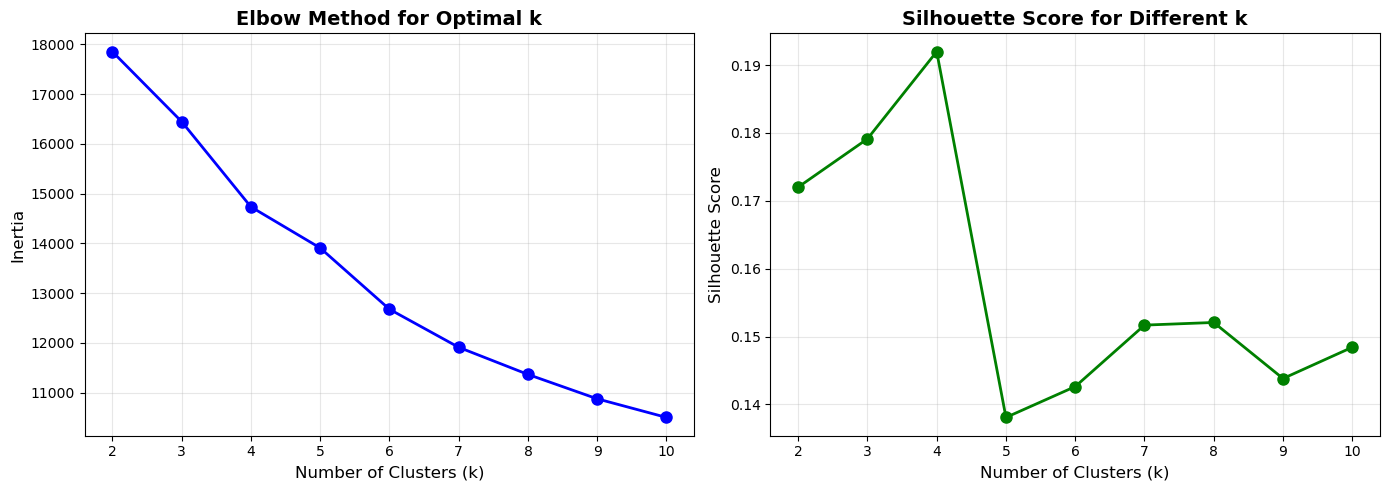

Elbow and Silhouette analysis plots saved!


In [60]:
# Plot Elbow and Silhouette Score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette Score
axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score for Different k', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/elbow_silhouette_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Elbow and Silhouette analysis plots saved!")

In [53]:
# Determine Optimal Number of Clusters using Elbow Method
inertias = []
silhouette_scores = []
K_range = range(2, 11)


from sklearn.metrics import silhouette_score

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

print("Inertias:", inertias)
print("Silhouette Scores:", silhouette_scores)

Inertias: [17851.557706999363, 16446.115791769054, 14732.81488594669, 13906.998058232162, 12675.712300909232, 11910.800470522172, 11365.716000666163, 10875.497430454885, 10501.600727147441]
Silhouette Scores: [0.17201551570197615, 0.17912856513775172, 0.19197758263588638, 0.13809166584223903, 0.14263832122401895, 0.15169084276395473, 0.15207980193053636, 0.14382242401498313, 0.14843107637107497]


In [52]:
# Standardize Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features standardized!")
print(f"Scaled data shape: {X_scaled.shape}")
print(f"Mean of scaled features: {X_scaled.mean(axis=0)[:5]}")  # Should be close to 0
print(f"Std of scaled features: {X_scaled.std(axis=0)[:5]}")   # Should be close to 1

Features standardized!
Scaled data shape: (2000, 11)
Mean of scaled features: [-4.33431069e-16  1.06581410e-17  1.68753900e-17 -4.97379915e-17
 -2.93098879e-17]
Std of scaled features: [1. 1. 1. 1. 1.]


In [51]:
# Prepare clustering features
features_for_clustering = [
    'age',
    'satisfaction_score',
    'loan_applied_encoded',
    'client_type_encoded',
    'acquisition_purpose_encoded',
    'gender_encoded',
    'property_count',
    'total_spent',
    'avg_price',
    'max_price',
    'avg_floor_area'
]

X = segmentation_df[features_for_clustering].copy()

# Handle missing values
X = X.fillna(X.mean())

print("Features for clustering:")
print(X.head())
print(f"\nShape: {X.shape}")
print(f"\nMissing values: {X.isnull().sum().sum()}")

Features for clustering:
         age  satisfaction_score  loan_applied_encoded  client_type_encoded  \
0  58.067077                   4                     1                    1   
1  55.223437                   1                     0                    1   
2  67.162218                   4                     1                    1   
3  55.223437                   5                     0                    1   
4  55.223437                   5                     0                    0   

   acquisition_purpose_encoded  gender_encoded  property_count  total_spent  \
0                            0               0               4   1246764.72   
1                            0               1               5   1841095.93   
2                            0               1               5   1661457.59   
3                            0               1               6   1608263.51   
4                            1               1              13   3653385.38   

       avg_price  max_pri

In [50]:
# Merge client and property data
segmentation_df = clients_df.merge(client_property_stats, left_on='client_id', right_on='client_id', how='left')

# Fill missing property data with zeros
segmentation_df['property_count'] = segmentation_df['property_count'].fillna(0)
segmentation_df['total_spent'] = segmentation_df['total_spent'].fillna(0)
segmentation_df['avg_price'] = segmentation_df['avg_price'].fillna(0)
segmentation_df['max_price'] = segmentation_df['max_price'].fillna(0)
segmentation_df['avg_floor_area'] = segmentation_df['avg_floor_area'].fillna(0)

print("Client and property data merged!")
print(f"Total clients in segmentation data: {len(segmentation_df)}")
print(segmentation_df[['client_id', 'age', 'satisfaction_score', 'property_count', 'total_spent']].head(10))

Client and property data merged!
Total clients in segmentation data: 2000
  client_id        age  satisfaction_score  property_count  total_spent
0     C0001  58.067077                   4               4   1246764.72
1     C0002        NaN                   1               5   1841095.93
2     C0003  67.162218                   4               5   1661457.59
3     C0004        NaN                   5               6   1608263.51
4     C0005        NaN                   5              13   3653385.38
5     C0006  69.248460                   3               5   1514131.06
6     C0007        NaN                   5              11   3251147.83
7     C0008        NaN                   5               5   1476730.41
8     C0009  50.666667                   5               5   1820832.35
9     C0010        NaN                   3               5   1732434.00


In [49]:
# Prepare Data for Clustering - Create feature matrix
# Calculate age from date_of_birth
clients_df['date_of_birth'] = pd.to_datetime(clients_df['date_of_birth'], errors='coerce')
clients_df['age'] = (pd.Timestamp.now() - clients_df['date_of_birth']).dt.days / 365.25

# Encode categorical variables
le_client_type = LabelEncoder()
le_acquisition = LabelEncoder()
le_gender = LabelEncoder()
le_loan = LabelEncoder()

clients_df['client_type_encoded'] = le_client_type.fit_transform(clients_df['client_type'].fillna('Unknown'))
clients_df['acquisition_purpose_encoded'] = le_acquisition.fit_transform(clients_df['acquisition_purpose'].fillna('Unknown'))
clients_df['gender_encoded'] = le_gender.fit_transform(clients_df['gender'].fillna('Unknown'))
clients_df['loan_applied_encoded'] = le_loan.fit_transform(clients_df['loan_applied'].fillna('No'))

print("Encoded features created successfully!")

Encoded features created successfully!


In [48]:
# Aggregate property data by client
client_property_stats = properties_sold.groupby('client_ref').agg({
    'sale_price': ['count', 'sum', 'mean', 'max'],
    'floor_area_sqft': 'mean'
}).reset_index()

# Flatten column names
client_property_stats.columns = ['client_id', 'property_count', 'total_spent', 'avg_price', 'max_price', 'avg_floor_area']

print("Client Property Statistics:")
print(client_property_stats.head(10))
print(f"\nTotal clients with property data: {len(client_property_stats)}")

Client Property Statistics:
  client_id  property_count  total_spent      avg_price  max_price  \
0     C0001               4   1246764.72  311691.180000  496266.41   
1     C0002               5   1841095.93  368219.186000  505127.63   
2     C0003               5   1661457.59  332291.518000  584611.99   
3     C0004               6   1608263.51  268043.918333  606634.75   
4     C0005              13   3653385.38  281029.644615  628812.33   
5     C0006               5   1514131.06  302826.212000  435031.40   
6     C0007              11   3251147.83  295558.893636  484458.03   
7     C0008               5   1476730.41  295346.082000  537291.01   
8     C0009               5   1820832.35  364166.470000  580903.05   
9     C0010               5   1732434.00  346486.800000  480540.62   

   avg_floor_area  
0      983.885000  
1     1187.942000  
2     1058.110000  
3      937.103333  
4      927.296154  
5      989.590000  
6      995.693636  
7     1031.106000  
8     1305.644000  
9

In [47]:
# Data Cleaning - Clean property prices (remove $ and commas)
# Handle both string and numeric values
if properties_df['sale_price'].dtype == 'object':
    properties_df['sale_price'] = properties_df['sale_price'].str.replace('$', '').str.replace(',', '').astype(float)
else:
    properties_df['sale_price'] = properties_df['sale_price'].astype(float)

# Filter properties to only sold items with client references
properties_sold = properties_df[properties_df['listing_status'] == 'Sold'].copy()
print(f"Sold properties with client references: {len(properties_sold)}")
print(properties_sold.head())

Sold properties with client references: 7305
   listing_id  tower_number transaction_date unit_category  unit_number  \
0        1012             1       01-01-2024     Apartment           12   
1        1015             1       01-01-2024     Apartment           15   
2        1021             1       01-01-2024     Apartment           21   
3        1030             1       01-01-2024     Apartment           30   
4        2016             2       01-01-2024     Apartment           16   

   floor_area_sqft  sale_price listing_status client_ref  
0          1160.36   300385.62           Sold      C0027  
1           782.25   208930.81           Sold      C0097  
2           756.21   218585.92           Sold      C0113  
3           743.09   246172.68           Sold      C0141  
4           701.66   212265.67           Sold      C0146  


In [46]:
# Data Exploration
print("Clients Data Info:")
print(clients_df.head())
print("\n" + "="*50 + "\n")
print("Properties Data Info:")
print(properties_df.head())

Clients Data Info:
  client_id client_type first_name last_name date_of_birth gender country  \
0     C0001  Individual     Kareem       Liu    05-11-1968      F     USA   
1     C0002  Individual    Trystan   Oconnor    11/26/1962      M     USA   
2     C0003  Individual       Kale       Gay    04-07-1959      M     USA   
3     C0004  Individual    Russell     Gross    11/25/1959      M     USA   
4     C0005     Company    Marleez        Co     2/28/1976      M     USA   

       region acquisition_purpose  satisfaction_score loan_applied  \
0  California                Home                   4          Yes   
1  California                Home                   1           No   
2  California                Home                   4          Yes   
3  California                Home                   5           No   
4  California          Investment                   5           No   

  referral_channel  
0          Website  
1          Website  
2           Agency  
3          We

In [45]:
# Load Data
clients_df = pd.read_csv("../data/clients.csv")
properties_df = pd.read_csv("../data/properties.csv")

print(f"Clients data shape: {clients_df.shape}")
print(f"Properties data shape: {properties_df.shape}")
print("\nClients columns:", clients_df.columns.tolist())
print("\nProperties columns:", properties_df.columns.tolist())

Clients data shape: (2000, 12)
Properties data shape: (10000, 9)

Clients columns: ['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth', 'gender', 'country', 'region', 'acquisition_purpose', 'satisfaction_score', 'loan_applied', 'referral_channel']

Properties columns: ['listing_id', 'tower_number', 'transaction_date', 'unit_category', 'unit_number', 'floor_area_sqft', 'sale_price', 'listing_status', 'client_ref']


In [ ]:
# Import Required Libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


# Buyer Segmentation Analysis

This notebook performs customer segmentation using clustering techniques on buyer data combined with property transaction information.